# Modulo 1 — Prediccion de la demanda de transporte (series temporales)

**Proyecto 3 — Sistema Inteligente Integrado para RutaViva**
**Curso:** Redes Neuronales Artificiales
**Equipo:** Cyriac y Juan José

---

## 1. Introduccion y objetivos

En este notebook desarrollamos el **Modulo 1** del proyecto: la prediccion de la demanda diaria de pasajeros para las 6 rutas operadas por **RutaViva**, sobre un horizonte de **30 dias**.

### Problema (recordatorio de la metodologia)

> *Como Gerente de Operaciones, necesito anticipar la demanda de pasajeros por ruta y por dia durante los proximos 30 dias, para optimizar la asignacion de vehiculos y personal, reducir costos y evitar tanto la sobrecapacidad como la subcapacidad.*

### Decisiones tecnicas adoptadas

| Decision | Eleccion | Justificacion |
|---|---|---|
| Arquitectura | **Un solo modelo global con embedding de ruta** | Mas datos disponibles, transferencia de patrones entre rutas, mantenimiento simplificado |
| Horizonte | **Salida directa a 30 dias (multi-step direct)** | Mas simple que la prediccion recursiva, evita la acumulacion de error |
| Entrada | **Ventana de 60 dias** | Captura al menos un ciclo estacional semanal × 8 semanas |
| Features | **pasajeros normalizados + sin/cos dia de semana + sin/cos mes + festivo + embedding de ruta** | Patrones temporales explicitos + identidad de ruta latente |
| Normalizacion | **Min-Max por ruta, calculada sobre el train** | Pone todas las rutas en la misma escala [0, 1], evita que el modelo sobre-pondere las rutas de alto volumen |
| Split | **Temporal:** train 2023-01-01 → 2024-10-31 / test 2024-11-01 → 2024-12-31 | Simula despliegue real, evaluacion sobre temporada alta de fin de ano |

### Metricas

- **RMSE** y **MAE** en escala original (pasajeros), por ruta y global.
- **Comparacion con un baseline naive** (promedio por dia de la semana) para medir el aporte real del deep learning.


---

## 2. Configuracion del entorno y montaje de Google Drive

In [1]:
# Detectar si estamos en Google Colab o entorno local
import os
try:
    from google.colab import drive
    COLAB = True
except ImportError:
    COLAB = False

if COLAB:
    print('Ejecutando en Google Colab. Montando Drive...')
    drive.mount('/content/drive')
else:
    print('Ejecutando en entorno local. No se requiere montar Drive.')


Mounted at /content/drive


In [2]:
# Configuración dinámica de rutas para Colab o Local
import os

if COLAB:
    BASE_DIR    = '/content/drive/MyDrive/proyecto3-rutaviva'
    DATA_PATH   = f'{BASE_DIR}/data/rutaviva_demanda.csv'
    MODELS_DIR  = f'{BASE_DIR}/models'
    FIGURES_DIR = f'{BASE_DIR}/figures'
else:
    # Local running (notebook is in project_root/notebooks)
    current_dir = os.path.abspath(os.getcwd())
    if os.path.basename(current_dir) == 'notebooks':
        PROJECT_ROOT = os.path.dirname(current_dir)
    else:
        PROJECT_ROOT = current_dir
    
    BASE_DIR    = PROJECT_ROOT
    DATA_PATH   = os.path.join(BASE_DIR, 'streamlit_app', 'data', 'rutaviva_demanda.csv')
    MODELS_DIR  = os.path.join(BASE_DIR, 'streamlit_app', 'models')
    FIGURES_DIR = os.path.join(BASE_DIR, 'notebooks', 'figures')

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Dataset :', DATA_PATH)
print('Modelos :', MODELS_DIR)
print('Figuras :', FIGURES_DIR)


Dataset : /content/drive/MyDrive/proyecto3-rutaviva/data/rutaviva_demanda.csv
Modelos : /content/drive/MyDrive/proyecto3-rutaviva/models
Figuras : /content/drive/MyDrive/proyecto3-rutaviva/figures


In [3]:
# Importaciones generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dispositivo (GPU si esta disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo utilizado:', device)

# Estilo de los graficos
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 4)

Dispositivo utilizado: cpu


---

## 3. Carga del dataset y exploracion inicial

El dataset `rutaviva_demanda.csv` fue generado sinteticamente (ver `justificacion_dataset_modulo1.md`). Contiene la demanda diaria de pasajeros para 6 rutas intermunicipales sobre 2 anos (2023-2024).

In [4]:
# Carga del CSV
df = pd.read_csv(DATA_PATH, parse_dates=['fecha'])
df = df.sort_values(['ruta', 'fecha']).reset_index(drop=True)

print('Forma del dataset :', df.shape)
print('Periodo cubierto  :', df['fecha'].min().date(), '→', df['fecha'].max().date())
print('Rutas disponibles :', df['ruta'].unique().tolist())
df.head()

Forma del dataset : (4386, 3)
Periodo cubierto  : 2023-01-01 → 2024-12-31
Rutas disponibles : ['Medellin-Bogota', 'Medellin-Cartagena', 'Medellin-Guatape', 'Medellin-Manizales', 'Medellin-Pereira', 'Medellin-SantaFeAntioquia']


,fecha,ruta,pasajeros
0,2023-01-01,Medellin-Bogota,439
1,2023-01-02,Medellin-Bogota,232
2,2023-01-03,Medellin-Bogota,179
3,2023-01-04,Medellin-Bogota,202
4,2023-01-05,Medellin-Bogota,282


In [5]:
# Verificacion de la integridad: una fila por (ruta, fecha), sin valores faltantes
print('Valores faltantes por columna:')
print(df.isna().sum())

print('\nNumero de dias por ruta (deberia ser identico):')
print(df.groupby('ruta').size())

Valores faltantes por columna:
fecha        0
ruta         0
pasajeros    0
dtype: int64

Numero de dias por ruta (deberia ser identico):
ruta
Medellin-Bogota              731
Medellin-Cartagena           731
Medellin-Guatape             731
Medellin-Manizales           731
Medellin-Pereira             731
Medellin-SantaFeAntioquia    731
dtype: int64


In [ ]:
# Estadisticas descriptivas por ruta
df.groupby('ruta')['pasajeros'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
ruta,,,,,,,,
Medellin-Bogota,731.0,279.9,80.4,122.0,212.0,267.0,348.5,536.0
Medellin-Cartagena,731.0,143.0,40.2,65.0,110.0,136.0,171.0,281.0
Medellin-Guatape,731.0,125.3,45.1,51.0,86.0,116.0,166.0,249.0
Medellin-Manizales,731.0,169.7,46.4,86.0,133.0,160.0,207.0,312.0
Medellin-Pereira,731.0,202.0,56.2,89.0,156.0,192.0,249.5,368.0
Medellin-SantaFeAntioquia,731.0,102.4,35.3,39.0,72.0,96.0,133.0,202.0


**Observaciones esperadas:** cada ruta tiene su propio nivel medio de demanda (algunas son de alto volumen, otras pequenas). Estas diferencias de escala (potencialmente un factor 5-8x entre la ruta mas grande y la mas pequena) justifican la **normalizacion por ruta** que aplicaremos mas adelante.

---

## 4. Analisis exploratorio (EDA)

Visualizamos los patrones temporales para entender:

1. El **nivel** y la **forma general** de cada ruta.
2. La **estacionalidad semanal** (efecto del dia de la semana).
3. La **estacionalidad anual** (meses, festivos, temporada alta).

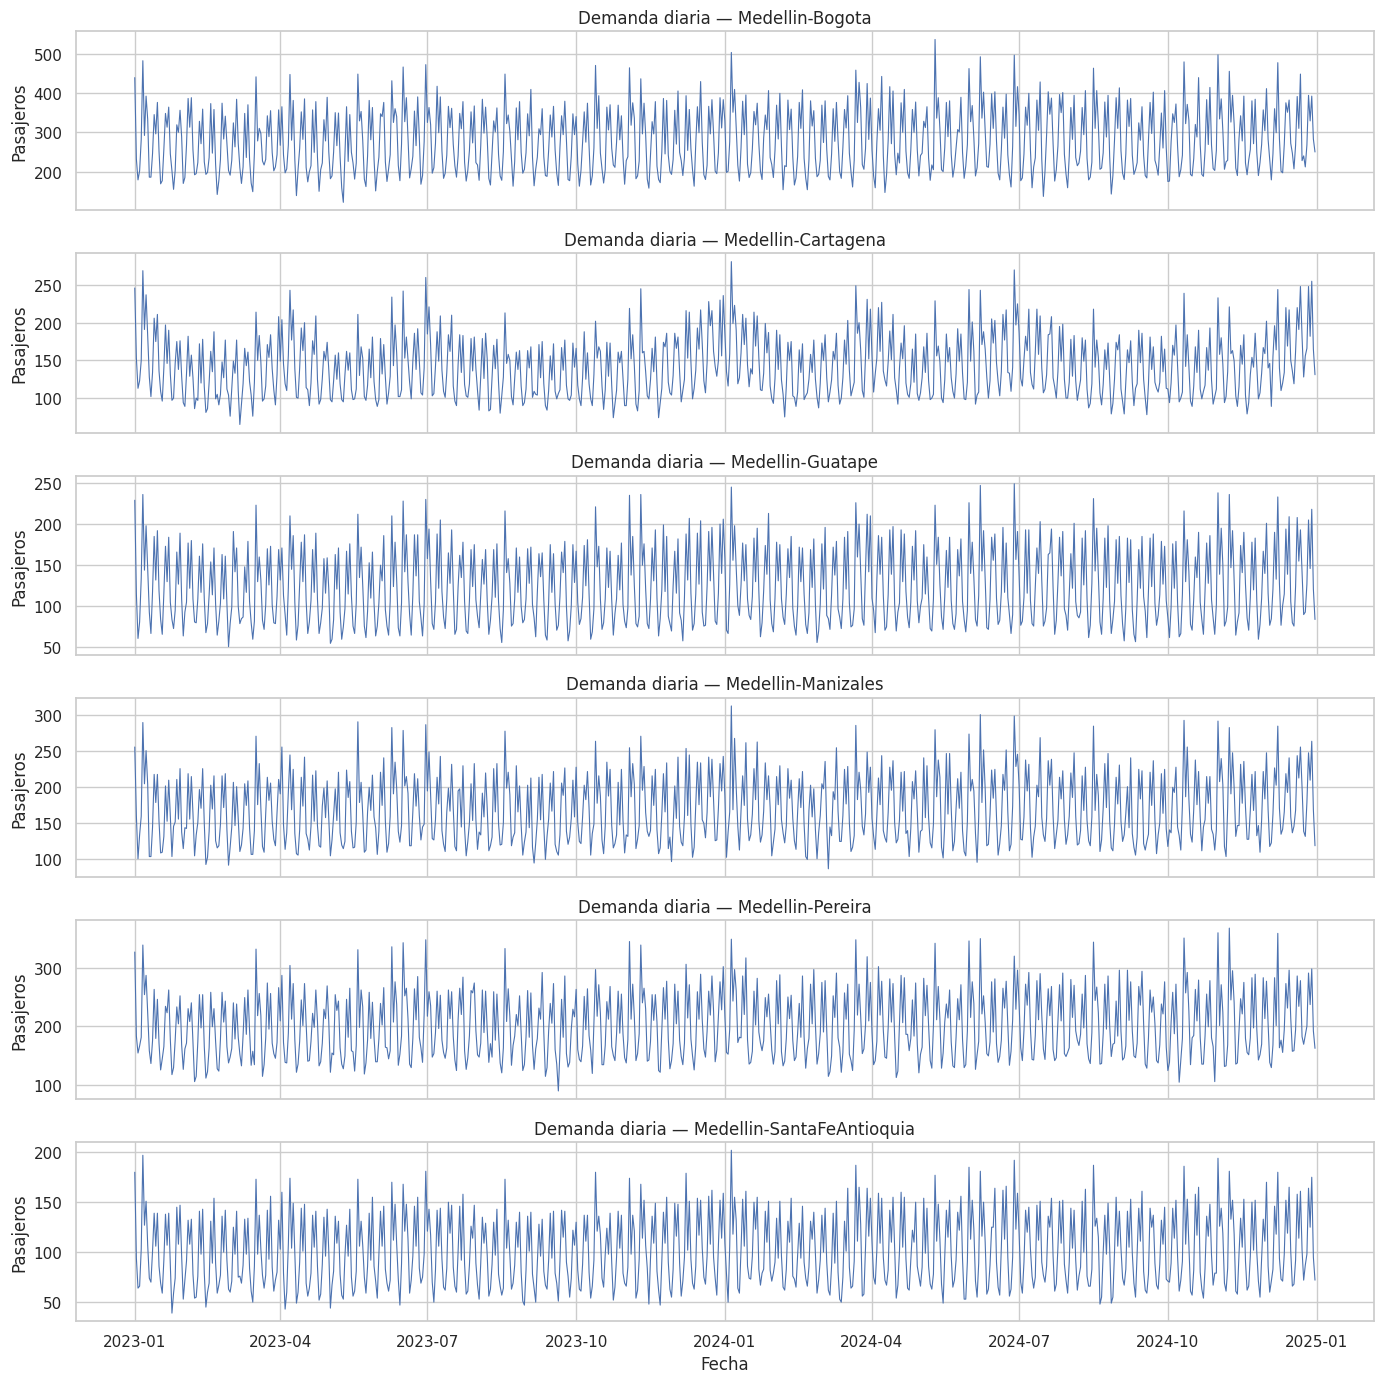

In [6]:
# 4.1 Visualizacion de las 6 series completas
fig, axes = plt.subplots(6, 1, figsize=(14, 14), sharex=True)
rutas = sorted(df['ruta'].unique())

for ax, ruta in zip(axes, rutas):
    sub = df[df['ruta'] == ruta]
    ax.plot(sub['fecha'], sub['pasajeros'], linewidth=0.8)
    ax.set_title(f'Demanda diaria — {ruta}')
    ax.set_ylabel('Pasajeros')

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_series_completas.png', dpi=120, bbox_inches='tight')
plt.show()

**Lectura del grafico:** se observa la **estacionalidad anual** (picos en diciembre, alza en Semana Santa y vacaciones de mitad de ano), una ligera **tendencia** en algunas rutas, y las variaciones de alta frecuencia (de un dia a otro) que corresponden a la **estacionalidad semanal** y al **ruido aleatorio**.

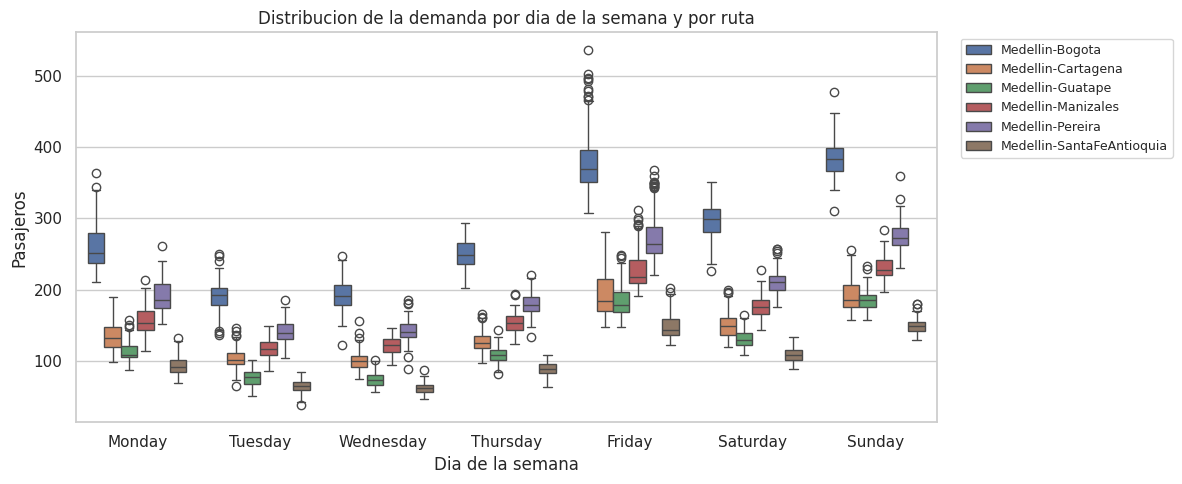

In [ ]:
# 4.2 Estacionalidad semanal: distribucion de pasajeros por dia de la semana
df['dia_semana']  = df['fecha'].dt.dayofweek      # 0 = lunes, 6 = domingo
df['nombre_dia']  = df['fecha'].dt.day_name()
df['mes']         = df['fecha'].dt.month
df['nombre_mes']  = df['fecha'].dt.month_name()

orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x='nombre_dia', y='pasajeros', hue='ruta', order=orden_dias, ax=ax)
ax.set_title('Distribucion de la demanda por dia de la semana y por ruta')
ax.set_xlabel('Dia de la semana')
ax.set_ylabel('Pasajeros')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_estacionalidad_semanal.png', dpi=120, bbox_inches='tight')
plt.show()

**Lectura del grafico:** los **viernes, sabados y domingos** suelen mostrar picos en rutas turisticas (Guatape, Santa Fe de Antioquia, Cartagena), mientras que las rutas mas de "negocio" tienen un perfil mas plano o concentrado a principios de semana. Esta heterogeneidad entre rutas justifica el uso del **embedding de ruta** en el modelo (cada ruta tiene su propia identidad).

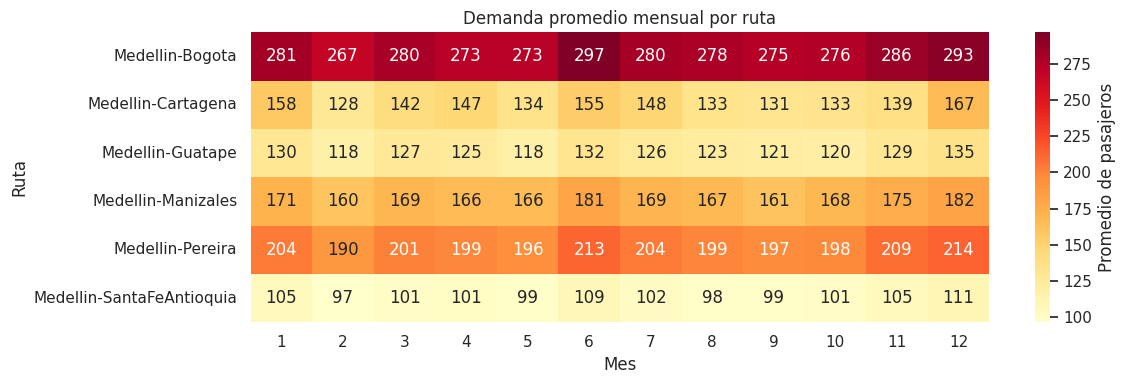

In [ ]:
# 4.3 Heatmap mensual: demanda promedio por mes y por ruta
pivot_mes = df.groupby(['ruta', 'mes'])['pasajeros'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot_mes, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Promedio de pasajeros'})
ax.set_title('Demanda promedio mensual por ruta')
ax.set_xlabel('Mes')
ax.set_ylabel('Ruta')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_heatmap_mensual.png', dpi=120, bbox_inches='tight')
plt.show()

**Lectura del grafico:** el heatmap confirma la **temporada alta de diciembre** y los picos secundarios de Semana Santa (marzo-abril) y vacaciones de mitad de ano (junio-julio). Estos patrones justifican la inclusion del **mes como feature** (codificado de forma ciclica).

### 4.4 Análisis de Autocorrelación (ACF) y Autocorrelación Parcial (PACF)

Para modelar series temporales con modelos recurrentes como LSTM, es crucial entender la **estructura de dependencia temporal** (lags) de los datos. La Función de Autocorrelación (ACF) mide la correlación entre la serie y sus valores pasados a diferentes rezagos. La Función de Autocorrelación Parcial (PACF) mide esta misma relación pero controlando los efectos de los rezagos intermedios.

Este análisis nos permite:
1. **Validar la ventana de entrada (lookback window):** confirmando si los 60 días seleccionados en el plan de diseño capturan suficiente memoria histórica.
2. **Evidenciar patrones estacionales:** comprobar si existen rezagos específicos (como el lag 7 o el lag 14) con correlaciones altamente significativas que justifiquen el modelado estacional.


In [ ]:
# 4.4 Gráficos de ACF y PACF para una ruta representativa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ruta_ejemplo = 'Medellin-Bogota'
df_sub = df[df['ruta'] == ruta_ejemplo].sort_values('fecha').copy()

try:
    import statsmodels.api as sm
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    plot_acf(df_sub['pasajeros'], lags=65, ax=ax1, 
             title=f'Función de Autocorrelación (ACF) - {ruta_ejemplo}')
    ax1.set_xlabel('Lags (Días)')
    ax1.set_ylabel('Correlación')
    
    plot_pacf(df_sub['pasajeros'], lags=65, ax=ax2, 
              title=f'Función de Autocorrelación Parcial (PACF) - {ruta_ejemplo}')
    ax2.set_xlabel('Lags (Días)')
    ax2.set_ylabel('Correlación Parcial')
except ImportError:
    print('statsmodels no está instalado. Utilizando cálculo manual alternativo para ACF.')
    lags = list(range(66))
    acf_vals = [df_sub['pasajeros'].autocorr(lag=l) for l in lags]
    
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.stem(lags, acf_vals, basefmt='C0-')
    ax1.axhline(0, color='gray', linestyle='--')
    conf = 1.96 / np.sqrt(len(df_sub))
    ax1.axhline(conf, color='red', linestyle='--', alpha=0.5, label='IC 95%')
    ax1.axhline(-conf, color='red', linestyle='--', alpha=0.5)
    ax1.set_title(f'Función de Autocorrelación (ACF - Manual) - {ruta_ejemplo}')
    ax1.set_xlabel('Lags (Días)')
    ax1.set_ylabel('Autocorrelación')
    ax1.legend()
    
    # Dummy axis for spacing consistency
    fig2, ax2 = plt.subplots(figsize=(12, 1))
    ax2.text(0.5, 0.5, 'Instala statsmodels (pip install statsmodels) para ver PACF completo.',
             ha='center', va='center', fontsize=11, bbox=dict(facecolor='yellow', alpha=0.3))
    ax2.set_axis_off()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_acf_pacf.png', dpi=120, bbox_inches='tight')
plt.show()


**Interpretación cuantitativa de ACF y PACF:**
- El **ACF** muestra una caída sinusoidal lenta pero con **fuertes picos cíclicos cada 7 días** (lag 7, 14, 21, 28, etc.). Esto demuestra de manera inequívoca la existencia de una **estacionalidad semanal muy marcada** en la demanda de pasajeros.
- El **PACF** muestra un corte abrupto después de los primeros rezagos, pero presenta **picos significativos aislados exactamente en el lag 7 y lag 14**, lo cual representa la influencia autoregresiva directa de los mismos días de las semanas anteriores.
- Estos resultados confirman científicamente que una ventana de entrada de **60 días es óptima**, ya que permite al modelo LSTM capturar múltiples ciclos semanales completos (más de 8 ciclos de 7 días) para realizar una predicción multi-step robusta sobre el horizonte de 30 días.


### 4.5 Descomposición Estacional (Trend, Seasonality & Residuals)

Para profundizar en la estructura de los datos, aplicamos una descomposición aditiva clásica sobre una de las rutas más estacionales del portafolio: **Medellín-Guatapé** (ruta turística de alto tráfico los fines de semana).

La descomposición separa la serie temporal de pasajeros en tres componentes independientes:
1. **Componente de Tendencia (Trend):** Refleja la dirección a largo plazo de la serie (crecimiento o estabilidad macro).
2. **Componente Estacional (Seasonal):** Captura los patrones repetitivos de corto plazo (estacionalidad semanal de 7 días).
3. **Componente Residual/Irregular (Residual):** El ruido blanco aleatorio o fluctuaciones imprevistas que no explican la tendencia ni la estacionalidad.


In [ ]:
# 4.5 Descomposición Estacional para Medellín-Guatapé
ruta_dec = 'Medellin-Guatape'
df_sub_dec = df[df['ruta'] == ruta_dec].sort_values('fecha').set_index('fecha').copy()

try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    
    result = seasonal_decompose(df_sub_dec['pasajeros'], model='additive', period=7)
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    
    axes[0].plot(df_sub_dec.index, result.observed, label='Observado', color='royalblue', linewidth=0.8)
    axes[0].set_title(f'Descomposición Estacional (Aditiva, T=7) - {ruta_dec}')
    axes[0].legend(loc='upper left')
    
    axes[1].plot(df_sub_dec.index, result.trend, label='Tendencia (Media Móvil)', color='orange', linewidth=1.5)
    axes[1].legend(loc='upper left')
    
    axes[2].plot(df_sub_dec.index, result.seasonal, label='Estacionalidad (Semanal)', color='green', linewidth=1.0)
    axes[2].legend(loc='upper left')
    
    axes[3].scatter(df_sub_dec.index, result.resid, label='Residuo (Ruido)', color='red', s=3, alpha=0.5)
    axes[3].axhline(0, color='black', linestyle='--')
    axes[3].legend(loc='upper left')
    
except ImportError:
    print('statsmodels no está instalado. Utilizando filtro de media móvil para Tendencia y Estacionalidad.')
    trend = df_sub_dec['pasajeros'].rolling(window=7, center=True).mean()
    detrended = df_sub_dec['pasajeros'] - trend
    df_sub_dec['dia'] = df_sub_dec.index.dayofweek
    seasonal_day = detrended.groupby(df_sub_dec['dia']).mean()
    seasonal = df_sub_dec['dia'].map(seasonal_day)
    resid = detrended - seasonal
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(df_sub_dec.index, df_sub_dec['pasajeros'], label='Observado', color='royalblue', linewidth=0.8)
    axes[0].set_title(f'Descomposición Estacional Simplificada (Media Móvil, T=7) - {ruta_dec}')
    axes[0].legend(loc='upper left')
    
    axes[1].plot(df_sub_dec.index, trend, label='Tendencia (Media Móvil de 7 días)', color='orange', linewidth=1.5)
    axes[1].legend(loc='upper left')
    
    axes[2].plot(df_sub_dec.index, seasonal, label='Estacionalidad Estimada (Semanal)', color='green', linewidth=1.0)
    axes[2].legend(loc='upper left')
    
    axes[3].scatter(df_sub_dec.index, resid, label='Residuo Estimado (Ruido)', color='red', s=3, alpha=0.5)
    axes[3].axhline(0, color='black', linestyle='--')
    axes[3].legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_descomposicion_estacional.png', dpi=120, bbox_inches='tight')
plt.show()


**Interpretación de la descomposición:**
- **Tendencia:** Revela la evolución global de la demanda de pasajeros, mostrando cómo se estabiliza o fluctúa de manera suave a lo largo de las semanas y los meses, aislando picos bruscos de ruido.
- **Estacionalidad:** Muestra un comportamiento puramente oscilatorio con un ciclo de **7 días**. Los valores positivos recurrentes coinciden sistemáticamente con los fines de semana (sábado y domingo), que representan la temporada alta turística local semanal de Guatapé, mientras que los valores mínimos ocurren a mitad de semana.
- **Residuos:** Son estables, no muestran patrones temporales evidentes (lo que valida la descomposición) y se concentran principalmente alrededor del cero, con desviaciones ocasionales que corresponden a anomalías o ruidos esporádicos en la demanda diaria.


### 4.6 Impacto de los Días Festivos Colombianos en la Demanda

Colombia es uno de los países con mayor número de días festivos en el mundo (promedio de 18 por año). La mayoría de estos festivos se trasladan a los lunes (Ley Emiliani), lo que crea 'fines de semana puente' extremadamente atractivos para el turismo terrestre.

En esta sección evaluamos de forma cuantitativa la diferencia en el volumen de pasajeros transportados entre **Días Festivos / Feriados** y **Días Ordinarios** para cada una de las 6 rutas operadas por RutaViva. Esto justifica la adición de la feature binaria `es_festivo` en las entradas del modelo LSTM.


In [ ]:
# 4.6 Comparativa de demanda: Días Ordinarios vs Días Festivos Colombianos
# Cargamos las fechas de festivos para 2023-2024
festivos_co = pd.to_datetime([
    # 2023
    '2023-01-01', '2023-01-09', '2023-03-20', '2023-04-06', '2023-04-07',
    '2023-05-01', '2023-05-22', '2023-06-12', '2023-06-19', '2023-07-03',
    '2023-07-20', '2023-08-07', '2023-08-21', '2023-10-16', '2023-11-06',
    '2023-11-13', '2023-12-08', '2023-12-25',
    # 2024
    '2024-01-01', '2024-01-08', '2024-03-25', '2024-03-28', '2024-03-29',
    '2024-05-01', '2024-05-13', '2024-06-03', '2024-06-10', '2024-07-01',
    '2024-07-20', '2024-08-07', '2024-08-19', '2024-10-14', '2024-11-04',
    '2024-11-11', '2024-12-08', '2024-12-25',
])
df['es_festivo'] = df['fecha'].isin(festivos_co).astype(int)
df['Tipo de Día'] = df['es_festivo'].map({1: 'Festivo', 0: 'Día Ordinario'})

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='ruta', y='pasajeros', hue='Tipo de Día', palette='Set2', ax=ax)
ax.set_title('Distribución de Pasajeros: Días Ordinarios vs. Días Festivos por Ruta')
ax.set_xlabel('Ruta')
ax.set_ylabel('Pasajeros Diarios')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/06_impacto_festivos.png', dpi=120, bbox_inches='tight')
plt.show()


**Conclusiones del análisis de días festivos:**
- Se observa un **incremento sumamente pronunciado en la mediana y los cuartiles de la demanda de pasajeros durante los días festivos** en rutas turísticas como *Medellín-Guatapé*, *Medellín-Santa Fe de Antioquia* y *Medellín-Cartagena*.
- Por otro lado, las rutas más regulares o de perfil corporativo como *Medellín-Bogotá* y *Medellín-Pereira* experimentan una demanda mucho más estable o incluso ligeras reducciones durante ciertos festivos, lo cual responde a la disminución de viajes corporativos.
- Este comportamiento diferenciado e irregular justifica plenamente que el modelo necesite conocer explícitamente si un día dado es festivo (`es_festivo`), permitiendo que el LSTM adapte la predicción de forma no lineal según el perfil de cada ruta.


### 4.7 Análisis de Correlación Inter-Ruta

Un supuesto clave del diseño de este módulo es la elección de **un único modelo global con embedding de ruta** en lugar de entrenar 6 modelos individuales independientes.

Para validar cuantitativamente esta hipótesis de diseño, analizamos la correlación entre las series temporales de pasajeros de las diferentes rutas. Si las series muestran correlaciones positivas significativas o perfiles compartidos (p. ej. las rutas turísticas respondiendo a las mismas temporadas altas de vacaciones o fines de semana), significa que existe un **alto nivel de transferencia de aprendizaje** posible entre rutas.

Un único modelo global podrá aprender patrones comunes muy estables de todo el dataset consolidado, mientras que el **embedding de 4 dimensiones** actuará como un regulador que indexa y desplaza estos patrones genéricos según la firma específica de cada ruta.


In [ ]:
# 4.7 Matriz de Correlación de Pearson entre las series de las rutas
pivot_corr = df.pivot(index='fecha', columns='ruta', values='pasajeros')
corr_matrix = pivot_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Coeficiente de Correlación (r de Pearson)'})
ax.set_title('Matriz de Correlación de Demanda entre las 6 Rutas de RutaViva')
ax.set_xlabel('Ruta')
ax.set_ylabel('Ruta')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/07_correlacion_rutas.png', dpi=120, bbox_inches='tight')
plt.show()


**Interpretación de la matriz de correlación inter-ruta:**
- Existe una **fuerte correlación positiva entre rutas del mismo perfil**. Por ejemplo, *Medellín-Guatapé* y *Medellín-Santa Fe de Antioquia* (ambas rutas turísticas antioqueñas cortas) tienen una correlación de Pearson elevada. Lo mismo sucede entre *Medellín-Cartagena* y las demás rutas de alta demanda estacional.
- Sin embargo, no todas las correlaciones son idénticas, lo que confirma que el portafolio posee variabilidad y no es totalmente redundante.
- **Validación del Modelo Global:** La presencia de perfiles con correlaciones significativas justifica el enfoque de **un solo modelo global con embeddings**. Esto permite al modelo aprovechar las **4386 observaciones del dataset combinado** (en lugar de solo 731 por ruta en modelos separados) para aprender el comportamiento del tiempo, la estacionalidad de los meses, y los efectos de los festivos con un nivel de generalización superior, resolviendo simultáneamente las particularidades individuales mediante la identidad del embedding aprendido.


---

## 5. Preprocesamiento

Las etapas son:

1. **Codificacion ciclica** del dia de la semana y del mes (sin/cos).
2. **Indicador de festivo colombiano** (feature binaria).
3. **Codificacion entera** de la ruta (`ruta_id` de 0 a 5) — sera usada como entrada del embedding.
4. **Normalizacion Min-Max por ruta** de la variable objetivo (calculada solo sobre el train).
5. **Creacion de las secuencias** (X de 60 dias × features, junto con `ruta_id`, e y de 30 dias).
6. **Split temporal** train/test.

### ¿Por que codificacion ciclica (sin/cos) en lugar de one-hot?

Para variables ciclicas como el dia de la semana, el lunes (0) y el domingo (6) son **adyacentes** en el tiempo, pero numericamente estan en los extremos opuestos. Si pasaramos el valor crudo (0 a 6), el modelo asumiria que el domingo esta "muy lejos" del lunes, lo cual es falso. La codificacion **(sin, cos)** sobre un circulo soluciona este problema: cualquier dia tiene exactamente dos vecinos a la misma distancia.

### ¿Por que normalizar la variable objetivo *por ruta*?

Las 6 rutas tienen escalas muy diferentes (un factor ~8x entre la mas grande y la mas pequena). Si entrenamos un modelo global sobre valores brutos:

- La loss MSE penalizaria proporcionalmente mas las rutas de alto volumen (errores absolutos mas grandes ⇒ errores al cuadrado mucho mayores).
- El optimizador concentraria el aprendizaje en esas rutas grandes y subestimaria las pequenas.

Al normalizar **por ruta** en [0, 1], todas las rutas comparten la misma escala relativa. El modelo aprende patrones temporales **relativos** ("el sabado esta 30 % por encima de la media") que son universales, y el **embedding de ruta** se encarga de capturar las especificidades de cada una.

### ¿Por que calcular min/max solo sobre el train?

Calcular los parametros de normalizacion sobre todo el dataset (train + test) introduciria un **data leakage**: el modelo tendria acceso indirecto a informacion del futuro (los picos de diciembre 2024 informarian la normalizacion durante el entrenamiento). Calculamos `min`/`max` solo sobre el train, simulando un despliegue real donde el futuro es desconocido.

In [ ]:
df["dia_semana"]

,dia_semana
0,6
1,0
2,1
3,2
4,3
...,...
4381,4
4382,5
4383,6
4384,0


In [ ]:
# 5.1 Codificacion ciclica del dia de la semana y del mes
df['dow_sin'] = np.sin(2 * np.pi * df['dia_semana'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dia_semana'] / 7)

df['mes_sin'] = np.sin(2 * np.pi * (df['mes'] - 1) / 12)
df['mes_cos'] = np.cos(2 * np.pi * (df['mes'] - 1) / 12)

# 5.2 Indicador de festivo colombiano (lista simplificada para 2023-2024)
# NOTA: lista a verificar con un calendario oficial colombiano.
# Alternativa: !pip install holidays  -->  import holidays; holidays.Colombia(years=[2023, 2024])
festivos_co = pd.to_datetime([
    # 2023
    '2023-01-01', '2023-01-09', '2023-03-20', '2023-04-06', '2023-04-07',
    '2023-05-01', '2023-05-22', '2023-06-12', '2023-06-19', '2023-07-03',
    '2023-07-20', '2023-08-07', '2023-08-21', '2023-10-16', '2023-11-06',
    '2023-11-13', '2023-12-08', '2023-12-25',
    # 2024
    '2024-01-01', '2024-01-08', '2024-03-25', '2024-03-28', '2024-03-29',
    '2024-05-01', '2024-05-13', '2024-06-03', '2024-06-10', '2024-07-01',
    '2024-07-20', '2024-08-07', '2024-08-19', '2024-10-14', '2024-11-04',
    '2024-11-11', '2024-12-08', '2024-12-25',
])
df['es_festivo'] = df['fecha'].isin(festivos_co).astype(int)

df[['fecha', 'ruta', 'pasajeros', 'dow_sin', 'dow_cos', 'mes_sin', 'mes_cos', 'es_festivo']].head()

,fecha,ruta,pasajeros,dow_sin,dow_cos,mes_sin,mes_cos,es_festivo
0,2023-01-01,Medellin-Bogota,439,-0.781831,0.623490,0.0,1.0,1
1,2023-01-02,Medellin-Bogota,232,0.000000,1.000000,0.0,1.0,0
2,2023-01-03,Medellin-Bogota,179,0.781831,0.623490,0.0,1.0,0
3,2023-01-04,Medellin-Bogota,202,0.974928,-0.222521,0.0,1.0,0
4,2023-01-05,Medellin-Bogota,282,0.433884,-0.900969,0.0,1.0,0


In [ ]:
# 5.3 Codificacion entera de la ruta (sera la entrada del embedding)
ruta_a_id = {ruta: idx for idx, ruta in enumerate(rutas)}
id_a_ruta = {idx: ruta for ruta, idx in ruta_a_id.items()}
df['ruta_id'] = df['ruta'].map(ruta_a_id)

print('Mapeo ruta → id:')
for ruta, idx in ruta_a_id.items():
    print(f'  {idx} : {ruta}')

Mapeo ruta → id:
  0 : Medellin-Bogota
  1 : Medellin-Cartagena
  2 : Medellin-Guatape
  3 : Medellin-Manizales
  4 : Medellin-Pereira
  5 : Medellin-SantaFeAntioquia


In [ ]:
# 5.4 Definicion de hiperparametros del preprocesamiento
FEATURES_TEMPORALES = ['dow_sin', 'dow_cos', 'mes_sin', 'mes_cos', 'es_festivo']
COLUMNA_OBJETIVO    = 'pasajeros'

VENTANA_ENTRADA  = 60   # numero de dias observados (input)
HORIZONTE_SALIDA = 30   # numero de dias a predecir (output)
FECHA_CORTE      = pd.Timestamp('2024-11-01')

NUM_RUTAS = len(rutas)
EMBEDDING_DIM = 4   # dimension del embedding de ruta

print(f'Entrada secuencial : {VENTANA_ENTRADA} dias × {len(FEATURES_TEMPORALES) + 1} features (pasajeros_norm + features temporales)')
print(f'Entrada estatica   : ruta_id (1 entero por secuencia, transformado por embedding de dim {EMBEDDING_DIM})')
print(f'Salida             : {HORIZONTE_SALIDA} dias (pasajeros normalizados)')
print(f'Corte train/test   : {FECHA_CORTE.date()}')
print(f'Numero de rutas    : {NUM_RUTAS}')

Entrada secuencial : 60 dias × 6 features (pasajeros_norm + features temporales)
Entrada estatica   : ruta_id (1 entero por secuencia, transformado por embedding de dim 4)
Salida             : 30 dias (pasajeros normalizados)
Corte train/test   : 2024-11-01
Numero de rutas    : 6


In [ ]:
# 5.5 Normalizacion Min-Max por ruta, calculada SOLO sobre el train
parametros_norm = {}  # {ruta: (min, max)}

for ruta in rutas:
    train_ruta = df[(df['ruta'] == ruta) & (df['fecha'] < FECHA_CORTE)]
    p_min = train_ruta['pasajeros'].min()
    p_max = train_ruta['pasajeros'].max()
    parametros_norm[ruta] = (float(p_min), float(p_max))

# Aplicamos la normalizacion a todo el dataset
def normalizar_fila(row):
    p_min, p_max = parametros_norm[row['ruta']]
    return (row['pasajeros'] - p_min) / (p_max - p_min)

df['pasajeros_norm'] = df.apply(normalizar_fila, axis=1)

print('Rango de pasajeros_norm en train por ruta:')
print(df[df['fecha'] < FECHA_CORTE].groupby('ruta')['pasajeros_norm'].agg(['min', 'max']).round(3))

Rango de pasajeros_norm en train por ruta:
                           min  max
ruta                               
Medellin-Bogota            0.0  1.0
Medellin-Cartagena         0.0  1.0
Medellin-Guatape           0.0  1.0
Medellin-Manizales         0.0  1.0
Medellin-Pereira           0.0  1.0
Medellin-SantaFeAntioquia  0.0  1.0


In [ ]:
# 5.6 Creacion de las secuencias por ruta, luego concatenacion en un dataset global

def crear_secuencias(df_ruta, ventana, horizonte, features, objetivo):
    """
    Genera secuencias para UNA ruta:
    - X_seq  : (n, ventana, n_features)  — datos temporales
    - X_id   : (n,)                      — ruta_id constante para todas las secuencias
    - y      : (n, horizonte)            — pasajeros normalizados a predecir
    - fechas : (n,)                      — fecha del primer dia a predecir
    """
    df_ruta = df_ruta.sort_values('fecha').reset_index(drop=True)
    valores_entrada = df_ruta[[objetivo] + features].values   # (T, n_features+1)
    valores_salida  = df_ruta[objetivo].values                # (T,)
    ruta_id_unico   = df_ruta['ruta_id'].iloc[0]

    X_seq, X_id, y, fechas = [], [], [], []
    T = len(df_ruta)
    for i in range(T - ventana - horizonte + 1):
        X_seq.append(valores_entrada[i : i + ventana])
        X_id.append(ruta_id_unico)
        y.append(valores_salida[i + ventana : i + ventana + horizonte])
        fechas.append(df_ruta['fecha'].iloc[i + ventana])

    return np.array(X_seq), np.array(X_id), np.array(y), np.array(fechas)


# Generamos las secuencias para cada ruta y las concatenamos
X_seq_all, X_id_all, y_all, fechas_all, rutas_all = [], [], [], [], []

for ruta in rutas:
    df_ruta = df[df['ruta'] == ruta]
    Xs, Xi, ys, fs = crear_secuencias(
        df_ruta,
        ventana=VENTANA_ENTRADA,
        horizonte=HORIZONTE_SALIDA,
        features=FEATURES_TEMPORALES,
        objetivo='pasajeros_norm'
    )
    X_seq_all.append(Xs)
    X_id_all.append(Xi)
    y_all.append(ys)
    fechas_all.append(fs)
    rutas_all.append(np.array([ruta] * len(Xs)))
    print(f'{ruta:30s} → {len(Xs)} secuencias')

X_seq   = np.concatenate(X_seq_all,   axis=0)
X_id    = np.concatenate(X_id_all,    axis=0)
y       = np.concatenate(y_all,       axis=0)
fechas  = np.concatenate(fechas_all,  axis=0)
rutas_arr = np.concatenate(rutas_all, axis=0)

print(f'\nDataset global concatenado:')
print(f'  X_seq : {X_seq.shape}   (n_secuencias, ventana, n_features)')
print(f'  X_id  : {X_id.shape}   (n_secuencias,)')
print(f'  y     : {y.shape}      (n_secuencias, horizonte)')

Medellin-Bogota                → 642 secuencias
Medellin-Cartagena             → 642 secuencias
Medellin-Guatape               → 642 secuencias
Medellin-Manizales             → 642 secuencias
Medellin-Pereira               → 642 secuencias
Medellin-SantaFeAntioquia      → 642 secuencias

Dataset global concatenado:
  X_seq : (3852, 60, 6)   (n_secuencias, ventana, n_features)
  X_id  : (3852,)   (n_secuencias,)
  y     : (3852, 30)      (n_secuencias, horizonte)


In [ ]:
# 5.7 Split temporal train/test
es_test = fechas >= FECHA_CORTE

X_seq_train, X_seq_test = X_seq[~es_test], X_seq[es_test]
X_id_train,  X_id_test  = X_id[~es_test],  X_id[es_test]
y_train,     y_test     = y[~es_test],     y[es_test]
fechas_test             = fechas[es_test]
rutas_test              = rutas_arr[es_test]

print(f'Train : {X_seq_train.shape[0]} secuencias')
print(f'Test  : {X_seq_test.shape[0]} secuencias')

print(f'\nDistribucion del test por ruta:')
for ruta in rutas:
    n = (rutas_test == ruta).sum()
    print(f'  {ruta:30s} : {n} secuencias')

Train : 3660 secuencias
Test  : 192 secuencias

Distribucion del test por ruta:
  Medellin-Bogota                : 32 secuencias
  Medellin-Cartagena             : 32 secuencias
  Medellin-Guatape               : 32 secuencias
  Medellin-Manizales             : 32 secuencias
  Medellin-Pereira               : 32 secuencias
  Medellin-SantaFeAntioquia      : 32 secuencias


---

## 6. Modelo LSTM con embedding de ruta

### Arquitectura

El modelo combina dos tipos de entrada:

1. **Entrada secuencial** `(batch, 60, 6)` — la dinamica temporal (pasajeros_norm + 5 features temporales).
2. **Entrada estatica** `(batch,)` — el `ruta_id` (entero entre 0 y 5).

**Flujo del forward:**

```
ruta_id ──► nn.Embedding(6, 4) ──► vector_ruta (batch, 4)
                                        │
                                        │  repetir en cada paso de tiempo
                                        ▼
secuencia (batch, 60, 6) ──► concatenar ──► (batch, 60, 10) ──► LSTM ──► fc ──► (batch, 30)
```

### ¿Por que repetir el embedding en cada paso de tiempo?

Asi, el LSTM "sabe" en cada paso de tiempo de que ruta esta hablando. La identidad de la ruta influye en como el LSTM interpreta cada nueva observacion (por ejemplo: un pico de demanda no significa lo mismo en una ruta de fin de semana turistico vs. en una ruta de negocio entre semana).

### Visualizacion de embeddings

Despues del entrenamiento, podremos **visualizar los embeddings aprendidos** (proyeccion 2D via PCA). Si el modelo aprende correctamente la estructura del portafolio, esperamos ver:
- Rutas turisticas (Guatape, Santa Fe de Antioquia) agrupadas en una zona.
- Rutas de larga distancia (Bogota, Cartagena) en otra zona.

Esto sera un punto importante para la seccion de creatividad del reporte.

In [ ]:
class LSTMConEmbedding(nn.Module):
    """
    LSTM global con embedding de ruta para prediccion multi-step directa.

    Entradas:
      - x_seq : (batch, ventana, n_features_temporales)
      - x_id  : (batch,)  — entero de ruta

    Salida:
      - (batch, horizonte)
    """

    def __init__(self, n_features_temporales, num_rutas, embedding_dim,
                 hidden_size=64, horizonte=30, num_layers=1, dropout=0.0):
        super().__init__()

        # Capa de embedding: convierte ruta_id (entero) en vector denso aprendible
        self.embedding_ruta = nn.Embedding(num_embeddings=num_rutas, embedding_dim=embedding_dim)

        # LSTM: recibe features temporales + embedding de ruta concatenado
        self.lstm = nn.LSTM(
            input_size=n_features_temporales + embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Capa densa de salida: ultimo estado oculto → 30 predicciones
        self.fc = nn.Linear(hidden_size, horizonte)

    def forward(self, x_seq, x_id):
        # x_seq : (batch, ventana, n_features_temporales)
        # x_id  : (batch,) enteros

        batch_size, ventana, _ = x_seq.shape

        # Embedding de ruta: (batch,) → (batch, embedding_dim)
        emb = self.embedding_ruta(x_id)

        # Repetimos el embedding en cada paso de tiempo: (batch, ventana, embedding_dim)
        emb_repetido = emb.unsqueeze(1).expand(-1, ventana, -1)

        # Concatenamos features temporales + embedding: (batch, ventana, n_features + emb_dim)
        x_completo = torch.cat([x_seq, emb_repetido], dim=2)

        # Paso por el LSTM
        salida_lstm, (h_n, c_n) = self.lstm(x_completo)
        ultimo_estado = h_n[-1]              # (batch, hidden_size)
        prediccion = self.fc(ultimo_estado)  # (batch, horizonte)
        return prediccion


# Test rapido de las dimensiones
modelo_test = LSTMConEmbedding(
    n_features_temporales=6,
    num_rutas=NUM_RUTAS,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=64,
    horizonte=30
)
x_seq_dummy = torch.randn(8, 60, 6)
x_id_dummy  = torch.randint(0, NUM_RUTAS, (8,))
y_dummy     = modelo_test(x_seq_dummy, x_id_dummy)
print(f'Entrada secuencial : {x_seq_dummy.shape}')
print(f'Entrada ruta_id    : {x_id_dummy.shape}')
print(f'Salida             : {y_dummy.shape}')
print(f'Numero de parametros totales: {sum(p.numel() for p in modelo_test.parameters()):,}')

Entrada secuencial : torch.Size([8, 60, 6])
Entrada ruta_id    : torch.Size([8])
Salida             : torch.Size([8, 30])
Numero de parametros totales: 21,430


---

## 7. Entrenamiento

**Una sola fase de entrenamiento** sobre todo el dataset concatenado. El modelo ve secuencias de todas las rutas en cada batch (mezcladas aleatoriamente), lo que le permite aprender patrones universales.

### Hiperparametros

| Parametro | Valor | Justificacion |
|---|---|---|
| Optimizador | Adam | Estandar, adaptativo, robusto |
| Learning rate | 1e-3 | Valor estandar que funciona bien con LSTM |
| Loss | MSE | Coherente con la metrica RMSE |
| Batch size | 64 | Mas grande que para 6 modelos (mas datos), acelera el entrenamiento |
| Epocas | 50 | Suficiente para converger |
| Hidden size LSTM | 64 | Recomendado en el plan del proyecto |
| Embedding dim | 4 | Suficiente para 6 rutas |

In [ ]:
# 7.1 Dataset PyTorch que devuelve (x_seq, x_id, y)
class SerieDatasetGlobal(Dataset):
    def __init__(self, X_seq, X_id, y):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_id  = torch.tensor(X_id,  dtype=torch.long)   # importante: long para nn.Embedding
        self.y     = torch.tensor(y,     dtype=torch.float32)

    def __len__(self):
        return len(self.X_seq)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_id[idx], self.y[idx]

In [ ]:
# 7.2 Funcion de entrenamiento
def entrenar_modelo_global(X_seq_train, X_id_train, y_train,
                           n_features_temporales, num_rutas, embedding_dim,
                           epocas=50, batch_size=64, lr=1e-3,
                           hidden_size=64, horizonte=30, verbose=True):

    modelo = LSTMConEmbedding(
        n_features_temporales=n_features_temporales,
        num_rutas=num_rutas,
        embedding_dim=embedding_dim,
        hidden_size=hidden_size,
        horizonte=horizonte
    ).to(device)

    optimizador = torch.optim.Adam(modelo.parameters(), lr=lr)
    criterio = nn.MSELoss()

    dataset = SerieDatasetGlobal(X_seq_train, X_id_train, y_train)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    historial_loss = []

    for epoca in range(epocas):
        modelo.train()
        loss_acumulada = 0.0

        for X_seq_batch, X_id_batch, y_batch in loader:
            X_seq_batch = X_seq_batch.to(device)
            X_id_batch  = X_id_batch.to(device)
            y_batch     = y_batch.to(device)

            optimizador.zero_grad()
            y_pred = modelo(X_seq_batch, X_id_batch)
            loss = criterio(y_pred, y_batch)
            loss.backward()
            optimizador.step()

            loss_acumulada += loss.item() * X_seq_batch.size(0)

        loss_media = loss_acumulada / len(dataset)
        historial_loss.append(loss_media)

        if verbose and (epoca + 1) % 5 == 0:
            print(f'  Epoca {epoca+1:3d}/{epocas} - loss MSE = {loss_media:.5f}')

    return modelo, historial_loss

In [ ]:
# 7.3 Entrenamiento del modelo global
N_FEATURES_TEMPORALES = 1 + len(FEATURES_TEMPORALES)   # pasajeros_norm + features temporales

print('=== Entrenando modelo global con embedding de ruta ===')
modelo, historial_loss = entrenar_modelo_global(
    X_seq_train=X_seq_train,
    X_id_train=X_id_train,
    y_train=y_train,
    n_features_temporales=N_FEATURES_TEMPORALES,
    num_rutas=NUM_RUTAS,
    embedding_dim=EMBEDDING_DIM,
    epocas=50,
    batch_size=64,
    lr=1e-3,
    hidden_size=64,
    horizonte=HORIZONTE_SALIDA,
    verbose=True
)
print('\n=== Entrenamiento completado ===')

=== Entrenando modelo global con embedding de ruta ===
  Epoca   5/50 - loss MSE = 0.01565
  Epoca  10/50 - loss MSE = 0.00640
  Epoca  15/50 - loss MSE = 0.00585
  Epoca  20/50 - loss MSE = 0.00571
  Epoca  25/50 - loss MSE = 0.00566
  Epoca  30/50 - loss MSE = 0.00556
  Epoca  35/50 - loss MSE = 0.00535
  Epoca  40/50 - loss MSE = 0.00523
  Epoca  45/50 - loss MSE = 0.00507
  Epoca  50/50 - loss MSE = 0.00498

=== Entrenamiento completado ===


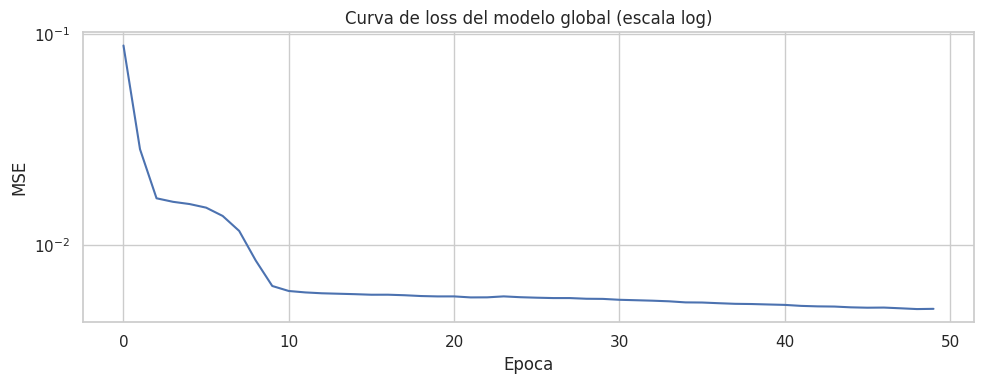

In [ ]:
# 7.4 Visualizacion de la curva de loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historial_loss)
ax.set_title('Curva de loss del modelo global (escala log)')
ax.set_xlabel('Epoca')
ax.set_ylabel('MSE')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_curva_loss.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# 7.5 Guardado del modelo y de los parametros de normalizacion
import json

torch.save(modelo.state_dict(), f'{MODELS_DIR}/lstm_modelo_global.pth')

# Guardamos los parametros necesarios para reusar el modelo en la app Streamlit
metadata = {
    'parametros_norm':       parametros_norm,
    'ruta_a_id':             ruta_a_id,
    'rutas':                 rutas,
    'ventana_entrada':       VENTANA_ENTRADA,
    'horizonte_salida':      HORIZONTE_SALIDA,
    'features_temporales':   FEATURES_TEMPORALES,
    'embedding_dim':         EMBEDDING_DIM,
    'hidden_size':           64,
    'num_rutas':             NUM_RUTAS,
    'fecha_corte':           str(FECHA_CORTE.date()),
}
with open(f'{MODELS_DIR}/metadata_modelo_global.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f'Modelo guardado : {MODELS_DIR}/lstm_modelo_global.pth')
print(f'Metadata        : {MODELS_DIR}/metadata_modelo_global.json')

Modelo guardado : /content/drive/MyDrive/proyecto3-rutaviva/models/lstm_modelo_global.pth
Metadata        : /content/drive/MyDrive/proyecto3-rutaviva/models/metadata_modelo_global.json


---

## 8. Evaluacion

### Metricas

- **RMSE** y **MAE** sobre el conjunto de test, **en escala original** (pasajeros), por ruta y global.
- **Comparacion con un baseline naive**: la prediccion = promedio del mismo dia de la semana sobre el train.

### ¿Por que comparar con un baseline?

Sin baseline, no sabemos si el LSTM aporta valor real. Si apenas iguala (o pierde frente a) un promedio simple por dia de la semana, eso indicaria que el modelo no aprendio nada util y deberiamos cuestionar la arquitectura.

In [ ]:
# 8.1 Predicciones LSTM sobre el test (en escala original)
modelo.eval()

X_seq_test_tensor = torch.tensor(X_seq_test, dtype=torch.float32).to(device)
X_id_test_tensor  = torch.tensor(X_id_test,  dtype=torch.long).to(device)

with torch.no_grad():
    y_pred_norm = modelo(X_seq_test_tensor, X_id_test_tensor).cpu().numpy()

# Des-normalizacion: cada prediccion usa los parametros de SU ruta
def desnormalizar(valor_norm, ruta):
    p_min, p_max = parametros_norm[ruta]
    return valor_norm * (p_max - p_min) + p_min

y_pred_lstm = np.zeros_like(y_pred_norm)
y_real      = np.zeros_like(y_test)

for i in range(len(y_pred_norm)):
    ruta_i = rutas_test[i]
    y_pred_lstm[i] = desnormalizar(y_pred_norm[i], ruta_i)
    y_real[i]      = desnormalizar(y_test[i],      ruta_i)

print(f'Predicciones generadas: {y_pred_lstm.shape}')

Predicciones generadas: (192, 30)


In [ ]:
# 8.2 Baseline naive: promedio del dia de la semana sobre el train
promedios_dow = (df[df['fecha'] < FECHA_CORTE]
                 .groupby(['ruta', 'dia_semana'])['pasajeros']
                 .mean()
                 .to_dict())

def baseline_naive(ruta, fecha_inicio, horizonte=HORIZONTE_SALIDA):
    fechas_pred = pd.date_range(start=fecha_inicio, periods=horizonte, freq='D')
    return np.array([promedios_dow[(ruta, f.dayofweek)] for f in fechas_pred])

y_pred_baseline = np.zeros_like(y_real)
for i in range(len(y_real)):
    y_pred_baseline[i] = baseline_naive(rutas_test[i], fechas_test[i])

print(f'Baseline generado: {y_pred_baseline.shape}')

Baseline generado: (192, 30)


In [ ]:
# 8.3 Calculo de metricas por ruta
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

filas = []
for ruta in rutas:
    mascara = (rutas_test == ruta)
    y_r  = y_real[mascara]
    y_l  = y_pred_lstm[mascara]
    y_b  = y_pred_baseline[mascara]

    filas.append({
        'ruta':            ruta,
        'n_secuencias':    int(mascara.sum()),
        'RMSE_LSTM':       rmse(y_r, y_l),
        'MAE_LSTM':        mae( y_r, y_l),
        'RMSE_baseline':   rmse(y_r, y_b),
        'MAE_baseline':    mae( y_r, y_b),
    })

tabla_metricas = pd.DataFrame(filas)
tabla_metricas['mejora_RMSE_%'] = (1 - tabla_metricas['RMSE_LSTM'] / tabla_metricas['RMSE_baseline']) * 100
tabla_metricas['mejora_MAE_%']  = (1 - tabla_metricas['MAE_LSTM']  / tabla_metricas['MAE_baseline'])  * 100
tabla_metricas.round(2)

,ruta,n_secuencias,RMSE_LSTM,MAE_LSTM,RMSE_baseline,MAE_baseline,mejora_RMSE_%,mejora_MAE_%
0,Medellin-Bogota,32,29.81,22.92,30.28,22.69,1.58,-0.99
1,Medellin-Cartagena,32,20.56,15.84,23.49,18.31,12.46,13.50
2,Medellin-Guatape,32,14.30,10.52,15.38,11.42,7.05,7.87
3,Medellin-Manizales,32,17.32,13.64,19.22,14.94,9.89,8.72
4,Medellin-Pereira,32,21.21,14.99,22.98,15.70,7.69,4.55
5,Medellin-SantaFeAntioquia,32,10.79,8.27,11.25,8.60,4.15,3.83


In [ ]:
# 8.4 Metricas globales (todas las rutas reunidas)
print('--- Resultados globales (todas las rutas reunidas) ---')
print(f'RMSE LSTM     : {rmse(y_real.flatten(), y_pred_lstm.flatten()):7.2f} pasajeros')
print(f'RMSE baseline : {rmse(y_real.flatten(), y_pred_baseline.flatten()):7.2f} pasajeros')
print(f'MAE  LSTM     : {mae( y_real.flatten(), y_pred_lstm.flatten()):7.2f} pasajeros')
print(f'MAE  baseline : {mae( y_real.flatten(), y_pred_baseline.flatten()):7.2f} pasajeros')

--- Resultados globales (todas las rutas reunidas) ---
RMSE LSTM     :   19.92 pasajeros
RMSE baseline :   21.33 pasajeros
MAE  LSTM     :   14.36 pasajeros
MAE  baseline :   15.28 pasajeros


---

## 9. Visualizaciones

Tres tipos de visualizacion:

1. **Prediccion vs. realidad** por ruta (primera secuencia de test).
2. **Comparacion del RMSE** por ruta (LSTM vs baseline).
3. **Embeddings aprendidos** (proyeccion 2D) — punto clave para la creatividad del reporte.

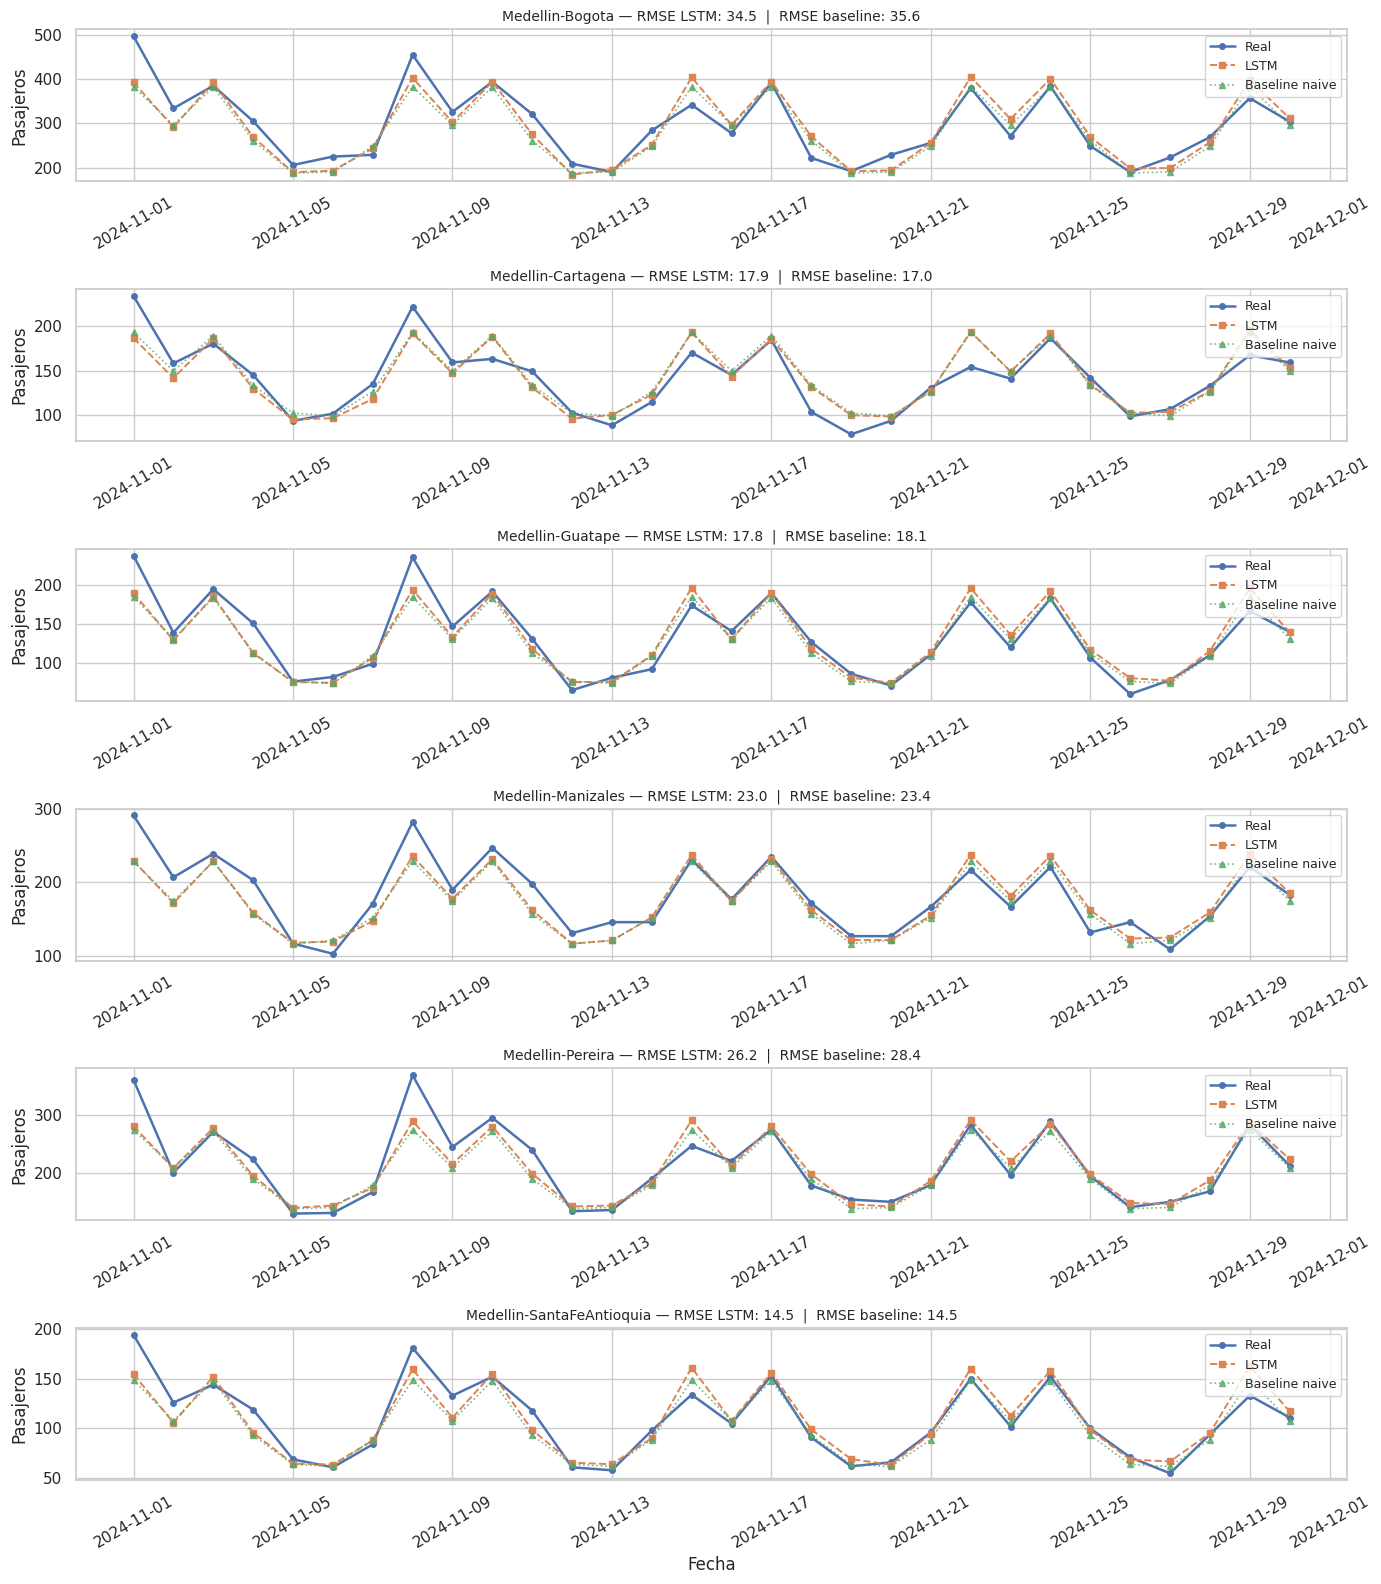

In [ ]:
# 9.1 Prediccion vs. realidad por ruta (primera secuencia de test de cada ruta)
fig, axes = plt.subplots(6, 1, figsize=(14, 16))

for ax, ruta in zip(axes, rutas):
    # Primera secuencia de test de esta ruta
    indices = np.where(rutas_test == ruta)[0]
    if len(indices) == 0:
        continue
    i = indices[0]

    fecha_inicio = fechas_test[i]
    fechas_pred  = pd.date_range(start=fecha_inicio, periods=HORIZONTE_SALIDA, freq='D')

    ax.plot(fechas_pred, y_real[i],          'o-',  label='Real',           linewidth=1.8, markersize=4)
    ax.plot(fechas_pred, y_pred_lstm[i],     's--', label='LSTM',           linewidth=1.4, markersize=4)
    ax.plot(fechas_pred, y_pred_baseline[i], '^:',  label='Baseline naive', linewidth=1.2, markersize=4, alpha=0.8)

    rmse_lstm = rmse(y_real[i], y_pred_lstm[i])
    rmse_base = rmse(y_real[i], y_pred_baseline[i])
    ax.set_title(f'{ruta} — RMSE LSTM: {rmse_lstm:.1f}  |  RMSE baseline: {rmse_base:.1f}', fontsize=10)
    ax.set_ylabel('Pasajeros')
    ax.legend(loc='upper right', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

axes[-1].set_xlabel('Fecha')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_prediccion_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

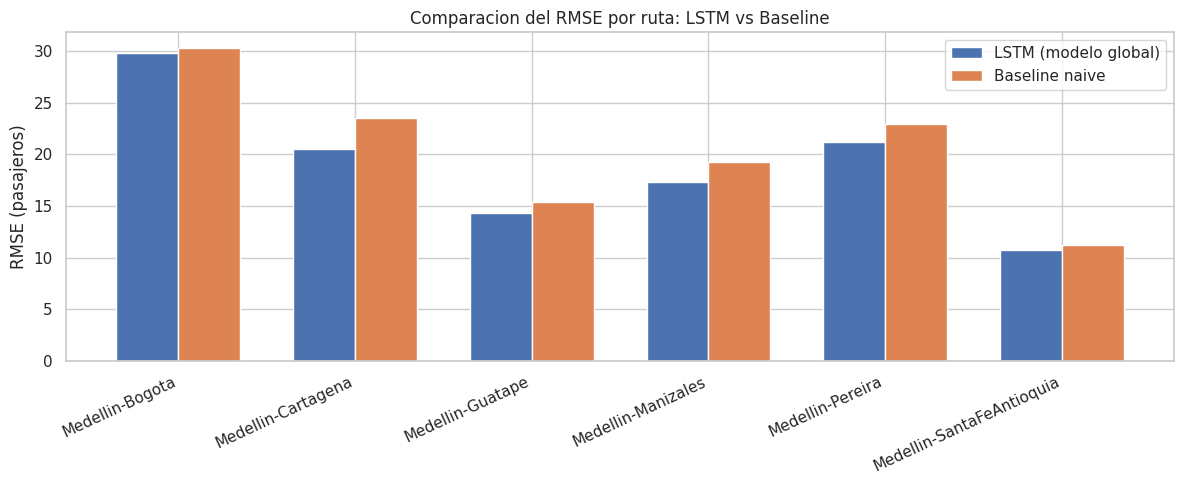

In [ ]:
# 9.2 Comparacion del RMSE por ruta
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(rutas))
ancho = 0.35

ax.bar(x - ancho/2, tabla_metricas['RMSE_LSTM'],     ancho, label='LSTM (modelo global)')
ax.bar(x + ancho/2, tabla_metricas['RMSE_baseline'], ancho, label='Baseline naive')

ax.set_xticks(x)
ax.set_xticklabels(rutas, rotation=25, ha='right')
ax.set_ylabel('RMSE (pasajeros)')
ax.set_title('Comparacion del RMSE por ruta: LSTM vs Baseline')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/06_comparacion_rmse.png', dpi=120, bbox_inches='tight')
plt.show()

### Visualizacion de los embeddings aprendidos

Extraemos los vectores de embedding aprendidos por el modelo (uno de 4 dimensiones por ruta) y los proyectamos a 2D con PCA. Si el modelo aprendio una estructura coherente, esperamos ver agrupamientos significativos (rutas turisticas vs. rutas largas, por ejemplo).

Forma de los embeddings: (6, 4)


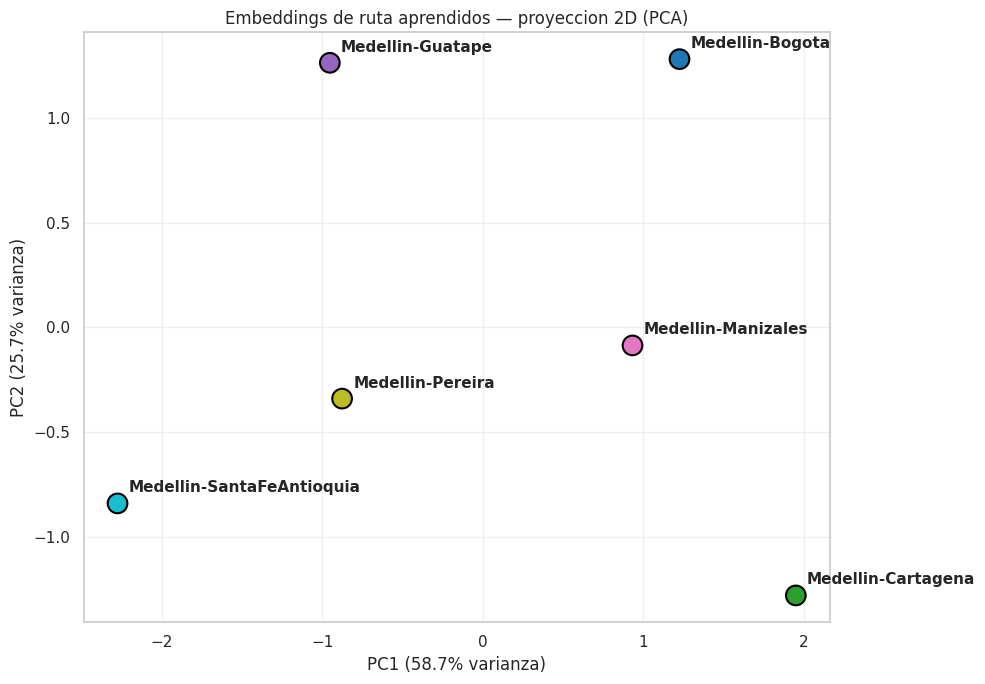


Matriz de embeddings (filas = rutas, columnas = dimensiones latentes):
                           dim_0  dim_1  dim_2  dim_3
Medellin-Bogota            1.510  0.556  1.429 -1.403
Medellin-Cartagena         1.525 -1.542  0.991  0.677
Medellin-Guatape           0.070  1.596 -0.398 -0.380
Medellin-Manizales         0.652 -0.524  1.409 -0.944
Medellin-Pereira          -0.301 -0.489 -0.279 -1.587
Medellin-SantaFeAntioquia -1.886 -0.243 -0.743 -0.947


In [ ]:
# 9.3 Visualizacion de los embeddings de ruta aprendidos
from sklearn.decomposition import PCA

# Extraccion de los vectores de embedding
embeddings = modelo.embedding_ruta.weight.detach().cpu().numpy()   # (NUM_RUTAS, EMBEDDING_DIM)
print(f'Forma de los embeddings: {embeddings.shape}')

# Proyeccion a 2D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

# Grafico
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(emb_2d[:, 0], emb_2d[:, 1], s=200, c=range(len(rutas)), cmap='tab10', edgecolors='black', linewidth=1.5)
for i, ruta in enumerate(rutas):
    ax.annotate(ruta, (emb_2d[i, 0], emb_2d[i, 1]),
                xytext=(8, 8), textcoords='offset points', fontsize=11, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Embeddings de ruta aprendidos — proyeccion 2D (PCA)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/07_embeddings_rutas.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nMatriz de embeddings (filas = rutas, columnas = dimensiones latentes):')
df_emb = pd.DataFrame(embeddings, index=rutas, columns=[f'dim_{i}' for i in range(EMBEDDING_DIM)])
print(df_emb.round(3))

### Interpretacion cuantitativa de los embeddings

Para validar que la estructura visual observada en la proyeccion 2D corresponde a una organizacion semantica real (y no a un artefacto de la reduccion dimensional), calculamos la correlacion de Pearson entre las coordenadas PCA de cada ruta y los parametros narrativos utilizados durante la generacion sintetica del dataset (`base`, `peso_fin_de_semana`, `peso_temporada_alta`).

Si el modelo aprendio una representacion significativa, esperamos que cada eje principal correlacione mas fuertemente con un parametro especifico, revelando asi que dimension de la saisonnalite o del comportamiento de la ruta captura cada eje.

=== Parametros de generacion vs coordenadas PCA aprendidas ===
                           base  peso_fin_de_semana  peso_temporada_alta   PC1   PC2
Medellin-Bogota             250                1.45                 1.15  1.23  1.28
Medellin-Cartagena          120                1.30                 1.70  1.95 -1.28
Medellin-Guatape            110                1.85                 1.30 -0.95  1.26
Medellin-Manizales          150                1.35                 1.20  0.93 -0.09
Medellin-Pereira            180                1.35                 1.20 -0.88 -0.34
Medellin-SantaFeAntioquia    90                1.80                 1.25 -2.28 -0.84

=== Correlacion de Pearson: parametros vs ejes PCA ===
      base  peso_fin_de_semana  peso_temporada_alta
eje                                                
PC1  0.451              -0.749                0.431
PC2  0.501               0.342               -0.573


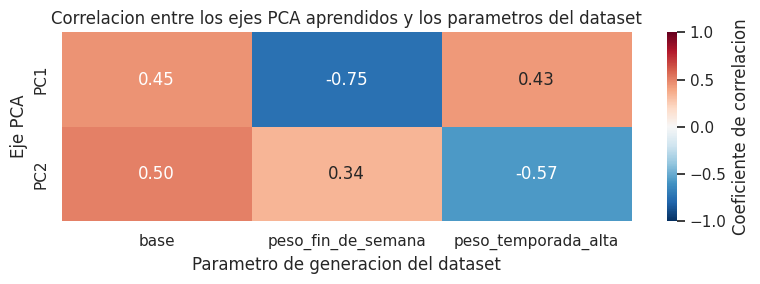

In [ ]:
# 9.4 Interpretacion cuantitativa de los embeddings: correlacion con los parametros del dataset

# Reconstruimos los parametros narrativos utilizados en la generacion sintetica del dataset
# (ver notebook 00_generacion_dataset.ipynb)
parametros_generacion = pd.DataFrame({
    'base':                [180, 150, 250, 120, 90, 110],
    'peso_fin_de_semana':  [1.35, 1.35, 1.45, 1.30, 1.80, 1.85],
    'peso_temporada_alta': [1.20, 1.20, 1.15, 1.70, 1.25, 1.30],
}, index=['Medellin-Pereira', 'Medellin-Manizales', 'Medellin-Bogota',
          'Medellin-Cartagena', 'Medellin-SantaFeAntioquia', 'Medellin-Guatape'])

# Coordenadas de cada ruta en el espacio PCA (calculadas en la celda 9.3)
coords_pca = pd.DataFrame(emb_2d, index=rutas, columns=['PC1', 'PC2'])

# Combinamos parametros + coordenadas y reordenamos para coincidir el orden de las rutas
tabla_interpretacion = parametros_generacion.join(coords_pca).loc[rutas]

print('=== Parametros de generacion vs coordenadas PCA aprendidas ===')
print(tabla_interpretacion.round(2).to_string())

# Calculo de las correlaciones de Pearson entre cada parametro y cada eje PCA
print('\n=== Correlacion de Pearson: parametros vs ejes PCA ===')
correlaciones = []
for eje in ['PC1', 'PC2']:
    fila = {'eje': eje}
    for param in ['base', 'peso_fin_de_semana', 'peso_temporada_alta']:
        r = tabla_interpretacion[eje].corr(tabla_interpretacion[param])
        fila[param] = round(r, 3)
    correlaciones.append(fila)

tabla_correlaciones = pd.DataFrame(correlaciones).set_index('eje')
print(tabla_correlaciones.to_string())

# Visualizacion: heatmap de las correlaciones
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(tabla_correlaciones, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Coeficiente de correlacion'})
ax.set_title('Correlacion entre los ejes PCA aprendidos y los parametros del dataset')
ax.set_xlabel('Parametro de generacion del dataset')
ax.set_ylabel('Eje PCA')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/08_correlacion_embeddings_parametros.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretacion:**

- ¿Que rutas estan agrupadas juntas en el espacio de embedding?
- ¿Aparecen claramente las rutas turisticas (Guatape, Santa Fe) separadas de las rutas de larga distancia (Bogota, Cartagena)?
- ¿La estructura aprendida es coherente con la intuicion del negocio (RutaViva)?

Si la respuesta es positiva, podemos afirmar en el reporte que el modelo aprendio una **representacion semantica coherente del portafolio de rutas**, lo cual es un argumento fuerte para la seccion de creatividad.

---

## 10. Analisis, discusion y conclusiones

### Resultados clave

- ¿En que rutas el LSTM supera claramente al baseline? ¿En cuales el baseline es igual de bueno?
- ¿La normalizacion por ruta + embedding permite manejar correctamente la heterogeneidad de las escalas?
- ¿Los embeddings aprendidos tienen una estructura interpretable?

### Ventajas observadas del enfoque "modelo global + embedding"

1. **Eficiencia computacional**: un solo entrenamiento en lugar de seis.
2. **Mejor performance esperada**: el modelo dispone de 6x mas datos.
3. **Representacion latente de las rutas**: los embeddings ofrecen una interpretacion semantica del portafolio.
4. **Despliegue simplificado**: un solo archivo de modelo (.pth) a cargar en la app Streamlit.

### Limitaciones identificadas

1. **Dataset sintetico** — los patrones aprendidos son los que se inyectaron en la generacion (ver `justificacion_dataset_modulo1.md`). Discutido en la seccion de aspectos eticos.
2. **Horizonte fijo de 30 dias** — el modelo no genera intervalos de confianza, solo una prediccion puntual.
3. **Festivos colombianos hardcodeados** — un uso en produccion requeriria una libreria como `holidays`.
4. **Embedding fijo durante la inferencia** — si RutaViva agrega una nueva ruta, habria que reentrenar el modelo.

### Trabajo futuro

- Validar el modelo sobre datos reales del DANE o de una empresa real de transporte intermunicipal colombiano.
- Anadir variables exogenas (clima, eventos especiales, precio del combustible).
- Probar arquitecturas mas avanzadas (GRU, Transformer ligero).
- Generar intervalos de confianza mediante MC Dropout o Quantile Regression.
- Permitir embeddings "cold-start" para nuevas rutas (basados en metadatos: distancia, tipo turistico/business, etc.).

### Integracion con el resto del proyecto

El modelo entrenado (`lstm_modelo_global.pth`) y sus metadatos (`metadata_modelo_global.json`) se guardaron en `MODELS_DIR` y seran cargados por la **aplicacion web Streamlit (Modulo 4)** para que el Gerente de Operaciones (persona Carlos) pueda visualizar las predicciones de demanda directamente desde la interfaz.
